# Evaluating the Final Model on 2025-03-01 to 2026-02-28

We had initially held out 2025-03-01 to 2026-02-28. We shall use TimeSeriesSplit to see how our chosen model performs.

First, we rerun Optuna with just 1 trial so that we can grab the best parameters that have been saved from 3xgboosted_prophet.ipynb.

## Load Packages

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import datetime

from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_squared_error, mean_absolute_percentage_error
from sklearn.linear_model import LinearRegression

from prophet import Prophet
from pandas.tseries.holiday import USFederalHolidayCalendar
from prophet.diagnostics import cross_validation, performance_metrics
from prophet.plot import plot_cross_validation_metric
from prophet.plot import add_changepoints_to_plot
import itertools

import warnings
from statsmodels.tools.sm_exceptions import ConvergenceWarning
warnings.simplefilter('ignore', ConvergenceWarning)

import logging
logging.getLogger("cmdstanpy").disabled = True

import xgboost as xgb
from xgboost import plot_importance

import optuna

## Add Features

In [3]:
def create_features(df):
    # create time series features based on time series index.
    df = df.copy()
    df['dayofweek'] = df.index.dayofweek
    df['quarter'] = df.index.quarter
    df['month'] = df.index.month
    df['year'] = df.index.year
    df['dayofyear'] = df.index.dayofyear
    df['dayofmonth'] = df.index.day
    df['weekofyear'] = df.index.isocalendar().week
    return df

def add_cyclic(df):
    # features to handly cyclic behavior
    target_map = df['y'].to_dict()
    df['dayofweek_sin'] = np.sin(2 * np.pi * df['dayofweek']/7)
    df['dayofweek_cos'] = np.cos(2 * np.pi * df['dayofweek']/7)
    df['month_sin'] = np.sin(2 * np.pi * df['month']/12)
    df['month_cos'] = np.cos(2 * np.pi * df['month']/12)
    return df

def add_lags(df):
    # lags
    target_map = df['y'].to_dict()
    df['lag15'] = (df.index - pd.Timedelta('15 days')).map(target_map)
    df['lag16'] = (df.index - pd.Timedelta('16 days')).map(target_map)
    return df

def add_seasonal_lags(df):
    # lags of various lengths for different levels of seasonality
    target_map = df['y'].to_dict()
    df['lag30'] = (df.index - pd.Timedelta('30 days')).map(target_map)
    df['lag60'] = (df.index - pd.Timedelta('60 days')).map(target_map)
    df['lag90'] = (df.index - pd.Timedelta('90 days')).map(target_map)
    df['lag120'] = (df.index - pd.Timedelta('120 days')).map(target_map)
    df['lag150'] = (df.index - pd.Timedelta('150 days')).map(target_map)
    df['lag180'] = (df.index - pd.Timedelta('180 days')).map(target_map)

    df['lag362'] = (df.index - pd.Timedelta('365 days')).map(target_map)
    df['lag363'] = (df.index - pd.Timedelta('365 days')).map(target_map)
    df['lag364'] = (df.index - pd.Timedelta('365 days')).map(target_map)
    df['lag365'] = (df.index - pd.Timedelta('365 days')).map(target_map)
    df['lag366'] = (df.index - pd.Timedelta('365 days')).map(target_map)
    df['lag367'] = (df.index - pd.Timedelta('365 days')).map(target_map)
    
    df['lag730'] = (df.index - pd.Timedelta('730 days')).map(target_map)
    df['lag1095'] = (df.index - pd.Timedelta('1095 days')).map(target_map)
    df['lag1460'] = (df.index - pd.Timedelta('1460 days')).map(target_map)
    df['lag1825'] = (df.index - pd.Timedelta('1825 days')).map(target_map)
    return df

def add_moving_averages(df):
    df = df.copy()
    df = df.sort_index()
    
    # Moving averages (using previous values only)
    # Must shift by 14 days because we do not want to let there be temporal leakage in our evaluations
    df['ma7'] = df['y'].shift(14).rolling(window=7).mean()
    df['ma30'] = df['y'].shift(14).rolling(window=30).mean()
    df['ma60'] = df['y'].shift(14).rolling(window=60).mean()
    df['ma90'] = df['y'].shift(14).rolling(window=90).mean()
    df['ma120'] = df['y'].shift(14).rolling(window=120).mean()
    df['ma150'] = df['y'].shift(14).rolling(window=150).mean()
    df['ma180'] = df['y'].shift(14).rolling(window=180).mean()
    df['ma365'] = df['y'].shift(14).rolling(window=365).mean()
    
    return df


## Add weather data.

import requests
import pandas as pd

lat, lon = 40.7831, -73.9712
start = "2020-01-01"
end   = "2026-02-28"

url = (
    "https://archive-api.open-meteo.com/v1/archive"
    f"?latitude={lat}&longitude={lon}"
    f"&start_date={start}&end_date={end}"
    "&daily=temperature_2m_max,temperature_2m_min,temperature_2m_mean,"
    "apparent_temperature_max,apparent_temperature_min,apparent_temperature_mean,"
    "precipitation_sum,snowfall_sum"
    "&timezone=America/New_York"
)

response = requests.get(url)
data = response.json()

if 'error' in data:
    nd = pd.read_csv("weatherdata.csv")
    nd = nd.set_index('date')
    wd = nd
    
else:
    wd = pd.DataFrame(data["daily"])
    wd["date"] = pd.to_datetime(wd["time"])
    wd = wd.set_index("date")


def add_weather_data(df, wd):
    df = df.copy()
    wd = wd.copy()
    
    # Ensure datetime index
    df.index = pd.to_datetime(df.index)
    wd.index = pd.to_datetime(wd.index)
    
    # Drop unnecessary columns
    if "time" in wd.columns:
        wd = wd.drop(columns=["time"])
    
    # Remove overlapping columns to avoid join errors
    overlap = wd.columns.intersection(df.columns)
    wd = wd.drop(columns=overlap)
    
    # Join on date index
    df = df.join(wd, how="left")
    
    return df

def add_more_weather_feature(df):
    target_map = df['apparent_temperature_min'].to_dict()
    df['apparent_temperature_min_lag14'] = (df.index - pd.Timedelta('14 days')).map(target_map)
    df['apparent_temperature_min_lag15'] = (df.index - pd.Timedelta('15 days')).map(target_map)
    df['apparent_temperature_min_lag16'] = (df.index - pd.Timedelta('16 days')).map(target_map)
    df['apparent_temperature_min_lag17'] = (df.index - pd.Timedelta('17 days')).map(target_map)
    df['apparent_temperature_min_lag18'] = (df.index - pd.Timedelta('18 days')).map(target_map)
    df['apparent_temperature_min_lag19'] = (df.index - pd.Timedelta('19 days')).map(target_map)
    df['apparent_temperature_min_lag20'] = (df.index - pd.Timedelta('20 days')).map(target_map)
    df['apparent_temperature_min_lag21'] = (df.index - pd.Timedelta('21 days')).map(target_map)

    df['apparent_temperature_min_lag30'] = (df.index - pd.Timedelta('30 days')).map(target_map)
    df['apparent_temperature_min_lag60'] = (df.index - pd.Timedelta('60 days')).map(target_map)
    df['apparent_temperature_min_lag90'] = (df.index - pd.Timedelta('90 days')).map(target_map)
    df['apparent_temperature_min_lag120'] = (df.index - pd.Timedelta('120 days')).map(target_map)
    df['apparent_temperature_min_lag150'] = (df.index - pd.Timedelta('150 days')).map(target_map)
    df['apparent_temperature_min_lag180'] = (df.index - pd.Timedelta('180 days')).map(target_map)
    df['apparent_temperature_min_lag210'] = (df.index - pd.Timedelta('210 days')).map(target_map)
    df['apparent_temperature_min_lag240'] = (df.index - pd.Timedelta('240 days')).map(target_map)
    df['apparent_temperature_min_lag270'] = (df.index - pd.Timedelta('270 days')).map(target_map)
    df['apparent_temperature_min_lag300'] = (df.index - pd.Timedelta('300 days')).map(target_map)
    df['apparent_temperature_min_lag330'] = (df.index - pd.Timedelta('330 days')).map(target_map)
    df['apparent_temperature_min_lag360'] = (df.index - pd.Timedelta('360 days')).map(target_map)
    df['apparent_temperature_min_lag365'] = (df.index - pd.Timedelta('365 days')).map(target_map)
    df['apparent_temperature_min_lag730'] = (df.index - pd.Timedelta('730 days')).map(target_map)

    target_map = df['temperature_2m_max'].to_dict()
    df['temperature_2m_max_lag14'] = (df.index - pd.Timedelta('14 days')).map(target_map)
    df['temperature_2m_max_lag30'] = (df.index - pd.Timedelta('30 days')).map(target_map)
    df['temperature_2m_max_lag60'] = (df.index - pd.Timedelta('60 days')).map(target_map)

    return df


date_range = pd.date_range(start="2020-01-01", end="2026-02-28")

# Generate US federal holidays
calendar = USFederalHolidayCalendar()
holidays = calendar.holidays(start=date_range.min(), end=date_range.max())

federal_holidays = pd.DataFrame({
    'holiday': 'federal_us',
    'ds': pd.to_datetime(holidays),
    'lower_window': 0,
    'upper_window': 1})

holidays = federal_holidays

from pandas.tseries.holiday import USFederalHolidayCalendar

def add_federal_holidays(df, custom_holidays=None):
    df = df.copy()
    
    # Ensure datetime index
    df.index = pd.to_datetime(df.index)
    
    cal = USFederalHolidayCalendar()
    holidays = cal.holidays(start=df.index.min(), end=df.index.max())
    
    if custom_holidays:
        for d in custom_holidays:
            if len(d) == 5:  # MM-DD format handling
                years = df.index.year.unique()
                for y in years:
                    holidays = holidays.append(pd.to_datetime([f"{y}-{d}"]))
            else:  # YYYY-MM-DD format handling
                holidays = holidays.append(pd.to_datetime([d]))
    
    holidays = holidays.drop_duplicates().sort_values()
    
    df["is_federal_holiday"] = df.index.isin(holidays).astype(int)
    
    return df

def add_law_flag(df, law_name: str, start_date: str):
    # Adds a binary column to indicate when a new law is active.
    df = df.copy()
    df.index = pd.to_datetime(df.index)
    start_dt = pd.to_datetime(start_date)
    # Create binary column: 1 if date >= start_date, else 0
    df[law_name] = (df.index >= start_dt).astype(int)
    
    return df

def add_new_lags(df, x):
    # lags
    target_map = df[x].to_dict()
    df[f'{x}lag15'] = (df.index - pd.Timedelta('15 days')).map(target_map)
    df[f'{x}lag16'] = (df.index - pd.Timedelta('16 days')).map(target_map)
    df[f'{x}lag17'] = (df.index - pd.Timedelta('17 days')).map(target_map)
    df[f'{x}lag18'] = (df.index - pd.Timedelta('18 days')).map(target_map)
    df[f'{x}lag19'] = (df.index - pd.Timedelta('19 days')).map(target_map)
    df[f'{x}lag20'] = (df.index - pd.Timedelta('20 days')).map(target_map)
    df[f'{x}lag21'] = (df.index - pd.Timedelta('21 days')).map(target_map)

    df[f'{x}lag30'] = (df.index - pd.Timedelta('30 days')).map(target_map)
    df[f'{x}lag365'] = (df.index - pd.Timedelta('365 days')).map(target_map)
    df[f'{x}lag730'] = (df.index - pd.Timedelta('730 days')).map(target_map)
    return df

In [4]:
ALL_FEATURES = {'dayofweek', 'quarter', 'month', 'year', 'dayofyear',
       'dayofmonth', 'weekofyear', 'dayofweek_sin', 'dayofweek_cos',
       'month_sin', 'month_cos', 'lag15', 'lag16', 'lag30', 'lag60', 'lag90',
       'lag120', 'lag150', 'lag180', 'lag362', 'lag363', 'lag364', 'lag365',
       'lag366', 'lag367', 'lag730', 'lag1095', 'lag1460', 'lag1825', 'ma7',
       'ma30', 'ma60', 'ma90', 'ma120', 'ma150', 'ma180', 'ma365',
       'temperature_2m_max', 'temperature_2m_min', 'temperature_2m_mean',
       'apparent_temperature_max', 'apparent_temperature_min',
       'apparent_temperature_mean', 'precipitation_sum', 'snowfall_sum',
       'apparent_temperature_min_lag14', 'apparent_temperature_min_lag15',
       'apparent_temperature_min_lag16', 'apparent_temperature_min_lag17',
       'apparent_temperature_min_lag18', 'apparent_temperature_min_lag19',
       'apparent_temperature_min_lag20', 'apparent_temperature_min_lag21',
       'apparent_temperature_min_lag30', 'apparent_temperature_min_lag60',
       'apparent_temperature_min_lag90', 'apparent_temperature_min_lag120',
       'apparent_temperature_min_lag150', 'apparent_temperature_min_lag180',
       'apparent_temperature_min_lag210', 'apparent_temperature_min_lag240',
       'apparent_temperature_min_lag270', 'apparent_temperature_min_lag300',
       'apparent_temperature_min_lag330', 'apparent_temperature_min_lag360',
       'apparent_temperature_min_lag365', 'apparent_temperature_min_lag730',
       'temperature_2m_max_lag14', 'temperature_2m_max_lag30',
       'temperature_2m_max_lag60', 'is_federal_holiday', 'Trash_Law',
       'New_Trash_Law', 'Rat_Mitigation_Zone', 'Rat_Czar_Appointed',
       'residuals', 'residualslag15', 'residualslag16', 'residualslag17',
       'residualslag18', 'residualslag19', 'residualslag20', 'residualslag21',
       'residualslag30', 'residualslag365', 'residualslag730', 'trend',
       'yhat_lower', 'yhat_upper'}

## Grab the Best Parameters by Using Stored Optuna Results

In [5]:
splits = 26 # from among 7, 13, 26, 


# this is the time series split we will work with
tscv = TimeSeriesSplit(gap=0, max_train_size=None, n_splits=splits, test_size=14)

study = optuna.create_study(
    direction="minimize",
    study_name="hybrid_model_feature_parameter_search",
    storage=f"sqlite:///xgbprophet_model{splits}.db",
    load_if_exists=True
)

best_params = study.best_params
print(best_params)

print("Best RMSE:", study.best_value)
print("Best params:", study.best_params)


best_features = [f for f in ALL_FEATURES if study.best_params.get(f, False)]

best_hyperparams = {k: v for k, v in study.best_params.items() if k not in ALL_FEATURES}
print("Selected Features:")
print(best_features)

print("\nBest Hyperparameters:")
print(best_hyperparams)

[I 2026-03-19 17:28:18,258] Using an existing study with name 'hybrid_model_feature_parameter_search' instead of creating a new one.


{'changepoint_prior_scale': 0.1476254975588991, 'seasonality_prior_scale': 0.3547339983371146, 'holidays_prior_scale': 2.274344908057226, 'n_estimators': 1916, 'max_depth': 4, 'learning_rate': 0.00198485296210223, 'subsample': 0.7100035979775448, 'colsample_bytree': 0.5770065237411632, 'gamma': 1.7585730706879485, 'min_child_weight': 8, 'reg_lambda': 1.1303130099058791, 'reg_alpha': 7.04862540806253, 'lag363': True, 'apparent_temperature_min_lag14': False, 'dayofweek_cos': False, 'is_federal_holiday': False, 'dayofyear': False, 'apparent_temperature_min_lag120': False, 'Rat_Czar_Appointed': False, 'ma365': False, 'lag30': False, 'lag730': False, 'apparent_temperature_min_lag16': True, 'residuals': False, 'residualslag15': True, 'Trash_Law': False, 'apparent_temperature_min_lag360': True, 'lag16': True, 'apparent_temperature_min_lag240': True, 'weekofyear': True, 'residualslag365': True, 'apparent_temperature_min_lag180': True, 'lag365': True, 'ma90': True, 'dayofweek': False, 'lag366':

In [6]:
prophet_keys = ["changepoint_prior_scale", "seasonality_prior_scale", "holidays_prior_scale"]

# extract subset
best_prophet_params = {k: best_hyperparams[k] for k in prophet_keys if k in best_hyperparams}


xgb_keys = ['n_estimators', 'max_depth', 'learning_rate', 'subsample', 'colsample_bytree', 'gamma', 'min_child_weight', 'reg_lambda', 'reg_alpha'] 

# extract subset
best_xgb_params = {k: best_hyperparams[k] for k in xgb_keys if k in best_hyperparams}




In [7]:
best_prophet_params

{'changepoint_prior_scale': 0.1476254975588991,
 'seasonality_prior_scale': 0.3547339983371146,
 'holidays_prior_scale': 2.274344908057226}

In [8]:
best_xgb_params

{'n_estimators': 1916,
 'max_depth': 4,
 'learning_rate': 0.00198485296210223,
 'subsample': 0.7100035979775448,
 'colsample_bytree': 0.5770065237411632,
 'gamma': 1.7585730706879485,
 'min_child_weight': 8,
 'reg_lambda': 1.1303130099058791,
 'reg_alpha': 7.04862540806253}

## Evaluate the Model on Holdout

In [9]:
# this is the time series split we will work with
tscv = TimeSeriesSplit(gap=0, max_train_size=None, n_splits=26, test_size=14)

# we import the data and clean it for future use
rs = pd.read_csv('../../scr/data/cleaned_rat_sightings_data/all_cleaned_rat_sightings.csv')
rs['created_date'] = pd.to_datetime(rs['created_date']) 
# mark cutoff dates, and also rename columns
rs = rs[rs['created_date']<'2026-03-01']
rs = rs[rs['created_date']>='2020-01-01']
rs = rs.groupby([rs['created_date'].dt.date]).size().reset_index(name='count')
rs.rename(columns={'created_date': 'ds', 'count': 'y'}, inplace=True)

save = rs['ds'].copy().values
rs = rs.set_index('ds')
rs.index = pd.to_datetime(rs.index)
rs['ds']=save
rs = create_features(rs)
rs = add_cyclic(rs)
rs = add_lags(rs)
rs = add_seasonal_lags(rs)
rs = add_moving_averages(rs)
rs = add_weather_data(rs,wd)
rs = add_more_weather_feature(rs)
rs = add_federal_holidays(rs, custom_holidays = ['12-31'])
rs = add_law_flag(rs, law_name='Trash_Law', start_date = '2024-03-01')
rs = add_law_flag(rs, law_name = 'New_Trash_Law', start_date = '2024-11-01')
rs = add_law_flag(rs, law_name='Rat_Mitigation_Zone', start_date = '2023-07-07')
rs = add_law_flag(rs, law_name='Rat_Czar_Appointed', start_date = '2023-04-12')

FEATURES = best_features

We cannot use future data and in particular, cannot use future weather data. We write a function that forward fills the relevant weather data using the last entry of weather data.

In [10]:
def forward_fill_rows(df, seed_row, include_columns=None):
    df_ffilled = df.copy()
    
    if include_columns is None:
        # if no columns specified, forward-fill all
        include_columns = df_ffilled.columns.tolist()
    
    for i in range(len(df_ffilled)):
        if i == 0:
            # first row takes seed_row for included columns
            for col in include_columns:
                df_ffilled.at[df_ffilled.index[i], col] = seed_row[col]
        else:
            # subsequent rows take previous row for included columns
            for col in include_columns:
                df_ffilled.at[df_ffilled.index[i], col] = df_ffilled.at[df_ffilled.index[i-1], col]
                
    return df_ffilled

In [11]:
# check that the forward_fill_rows() function works as intended

for i, (train_index, test_index) in enumerate(tscv.split(rs)):
    if i == 3:
        train = rs.iloc[train_index].copy()
        test = rs.iloc[test_index].copy()
        # Forward-fill test using last row of train, but leave 'ds' untouched
        test = forward_fill_rows(test, 
                                 seed_row=train.iloc[-1], 
                                 include_columns=['temperature_2m_max', 'temperature_2m_min', 'temperature_2m_mean',
                                                  'apparent_temperature_max', 'apparent_temperature_min',
                                                  'apparent_temperature_mean', 'precipitation_sum', 'snowfall_sum',])

        # Replace test with forward-filled version
        display(train[['temperature_2m_max', 'temperature_2m_min', 'temperature_2m_mean',
                                                  'apparent_temperature_max', 'apparent_temperature_min',
                                                  'apparent_temperature_mean', 'precipitation_sum', 'snowfall_sum',]].tail(4))
        display(test[['temperature_2m_max', 'temperature_2m_min', 'temperature_2m_mean',
                                                  'apparent_temperature_max', 'apparent_temperature_min',
                                                  'apparent_temperature_mean', 'precipitation_sum', 'snowfall_sum',]])

,temperature_2m_max,temperature_2m_min,temperature_2m_mean,apparent_temperature_max,apparent_temperature_min,apparent_temperature_mean,precipitation_sum,snowfall_sum
ds,,,,,,,,
2025-04-09,8.1,-1.8,3.1,5.3,-6.9,-1.0,0.0,0.00
2025-04-10,9.4,1.9,5.2,6.5,-1.0,1.9,0.7,0.00
2025-04-11,7.1,4.2,5.5,4.4,0.8,2.3,10.8,0.07
2025-04-12,5.7,1.7,3.9,1.3,-3.7,-0.5,17.1,1.54


,temperature_2m_max,temperature_2m_min,temperature_2m_mean,apparent_temperature_max,apparent_temperature_min,apparent_temperature_mean,precipitation_sum,snowfall_sum
ds,,,,,,,,
2025-04-13,5.7,1.7,3.9,1.3,-3.7,-0.5,17.1,1.54
2025-04-14,5.7,1.7,3.9,1.3,-3.7,-0.5,17.1,1.54
2025-04-15,5.7,1.7,3.9,1.3,-3.7,-0.5,17.1,1.54
2025-04-16,5.7,1.7,3.9,1.3,-3.7,-0.5,17.1,1.54
2025-04-17,5.7,1.7,3.9,1.3,-3.7,-0.5,17.1,1.54
2025-04-18,5.7,1.7,3.9,1.3,-3.7,-0.5,17.1,1.54
2025-04-19,5.7,1.7,3.9,1.3,-3.7,-0.5,17.1,1.54
2025-04-20,5.7,1.7,3.9,1.3,-3.7,-0.5,17.1,1.54
2025-04-21,5.7,1.7,3.9,1.3,-3.7,-0.5,17.1,1.54


In [12]:
rs.columns

Index(['y', 'ds', 'dayofweek', 'quarter', 'month', 'year', 'dayofyear',
       'dayofmonth', 'weekofyear', 'dayofweek_sin', 'dayofweek_cos',
       'month_sin', 'month_cos', 'lag15', 'lag16', 'lag30', 'lag60', 'lag90',
       'lag120', 'lag150', 'lag180', 'lag362', 'lag363', 'lag364', 'lag365',
       'lag366', 'lag367', 'lag730', 'lag1095', 'lag1460', 'lag1825', 'ma7',
       'ma30', 'ma60', 'ma90', 'ma120', 'ma150', 'ma180', 'ma365',
       'temperature_2m_max', 'temperature_2m_min', 'temperature_2m_mean',
       'apparent_temperature_max', 'apparent_temperature_min',
       'apparent_temperature_mean', 'precipitation_sum', 'snowfall_sum',
       'apparent_temperature_min_lag14', 'apparent_temperature_min_lag15',
       'apparent_temperature_min_lag16', 'apparent_temperature_min_lag17',
       'apparent_temperature_min_lag18', 'apparent_temperature_min_lag19',
       'apparent_temperature_min_lag20', 'apparent_temperature_min_lag21',
       'apparent_temperature_min_lag30', 'apparent

In [13]:
rs

,y,ds,dayofweek,quarter,month,year,dayofyear,dayofmonth,weekofyear,dayofweek_sin,...,apparent_temperature_min_lag365,apparent_temperature_min_lag730,temperature_2m_max_lag14,temperature_2m_max_lag30,temperature_2m_max_lag60,is_federal_holiday,Trash_Law,New_Trash_Law,Rat_Mitigation_Zone,Rat_Czar_Appointed
ds,,,,,,,,,,,,,,,,,,,,,
2020-01-01,17,2020-01-01,2,1,1,2020,1,1,1,0.974928,...,NaN,NaN,NaN,NaN,NaN,1,0,0,0,0
2020-01-02,40,2020-01-02,3,1,1,2020,2,2,1,0.433884,...,NaN,NaN,NaN,NaN,NaN,0,0,0,0,0
2020-01-03,41,2020-01-03,4,1,1,2020,3,3,1,-0.433884,...,NaN,NaN,NaN,NaN,NaN,0,0,0,0,0
2020-01-04,25,2020-01-04,5,1,1,2020,4,4,1,-0.974928,...,NaN,NaN,NaN,NaN,NaN,0,0,0,0,0
2020-01-05,17,2020-01-05,6,1,1,2020,5,5,1,-0.781831,...,NaN,NaN,NaN,NaN,NaN,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-02-24,26,2026-02-24,1,1,2,2026,55,24,9,0.781831,...,-4.6,-11.1,-0.3,-5.2,-2.8,0,1,1,1,1
2026-02-25,30,2026-02-25,2,1,2,2026,56,25,9,0.974928,...,0.1,-6.9,3.2,-3.1,-0.8,0,1,1,1,1
2026-02-26,40,2026-02-26,3,1,2,2026,57,26,9,0.433884,...,-1.4,-4.1,0.8,-7.3,0.9,0,1,1,1,1


In [12]:
results = []

for i, (train_index, test_index) in enumerate(tscv.split(rs)):

    train = rs.iloc[train_index].copy()
    test = rs.iloc[test_index].copy()


    # Forward-fill test using last row of train
    test = forward_fill_rows(test, 
                            seed_row=train.iloc[-1], 
                            include_columns=['temperature_2m_max', 'temperature_2m_min', 'temperature_2m_mean',
                                            'apparent_temperature_max', 'apparent_temperature_min',
                                            'apparent_temperature_mean', 'precipitation_sum', 'snowfall_sum',])

    model = Prophet(**best_prophet_params, holidays=holidays)
    model.add_country_holidays(country_name='US')
    model.fit(train)

    train_future = model.make_future_dataframe(periods=0, freq='D')
    train_forecast = model.predict(train_future)

    train_residuals = train['y'].values - train_forecast['yhat'].values

    residuals_df = pd.DataFrame({'ds': train['ds'],'y': train_residuals})

    train['residuals'] = train_residuals

    add_new_lags(train, 'residuals')

    train['trend'] = train_forecast['trend'].values
    train['yhat_lower'] = train_forecast['yhat_lower'].values
    train['yhat_upper'] = train_forecast['yhat_upper'].values

    X_train_residuals = train[FEATURES]
    y_train_residuals = residuals_df['y']

    # Train XGBoost
    xgb_model = xgb.XGBRegressor(**best_xgb_params)
    xgb_model.fit(X_train_residuals, y_train_residuals)

    # Prepare Test Data
    test['residuals'] = np.nan # need to add this otherwise it won't run

    dummy = pd.concat([train, test], axis=0)

    add_new_lags(dummy, 'residuals') # need to add the lags that test can actually see

    test = dummy.iloc[test_index].copy() # cut out the test set again

    # Prophet Forecast
    future = model.make_future_dataframe(periods=len(test), freq='D')
    prophet_forecast = model.predict(future)

    # add outputs of Prophet for use in the XGBoost model
    test.loc[:, 'trend'] = prophet_forecast[-len(test):]['trend'].values
    test.loc[:, 'yhat_lower'] = prophet_forecast[-len(test):]['yhat_lower'].values
    test.loc[:, 'yhat_upper'] = prophet_forecast[-len(test):]['yhat_upper'].values

    X_test = test[FEATURES]

    xgb_residual_preds = xgb_model.predict(X_test)

    y_pred = np.round(prophet_forecast['yhat'][-len(test):].values + xgb_residual_preds)
    y_true = test['y'].values

    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    results.append(rmse)    
    # Store the results for this fold

# Convert the results into a DataFrame
prophet_xgb_results_df = pd.DataFrame(results, columns=["RMSE"])

In [13]:
mean_rmse = prophet_xgb_results_df['RMSE'].mean()
prophet_xgb_results_df.loc['mean'] = [mean_rmse]

In [14]:
prophet_xgb_results_df

,RMSE
0,12.212406
1,8.839845
2,8.400680
3,10.402610
4,11.753419
5,14.466711
6,10.885771
7,10.757057
8,10.467637
9,8.589861


## Plots

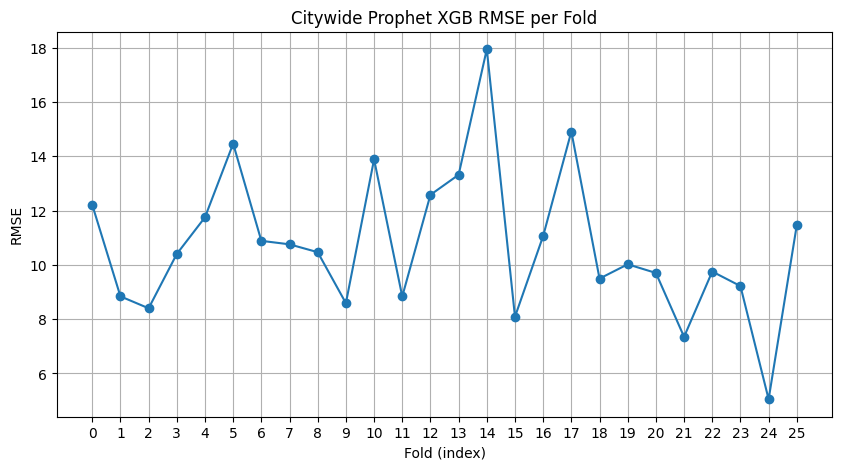

In [15]:
import matplotlib.pyplot as plt

# Reset index to turn the current index into a column
df_plot = prophet_xgb_results_df.reset_index()

# Drop the row where the original index was 'mean'
df_plot = df_plot[df_plot['index'] != 'mean']

# Plot RMSE using the numeric index as x-axis
plt.figure(figsize=(10, 5))
plt.plot(df_plot.index, df_plot['RMSE'], marker='o', linestyle='-')
plt.title("Citywide Prophet XGB RMSE per Fold")
plt.xlabel("Fold (index)")
plt.ylabel("RMSE")
plt.xticks(df_plot.index)  # show all fold numbers
plt.grid(True)
plt.show()


Text(0.5, 1.0, 'Total Cover Importance')

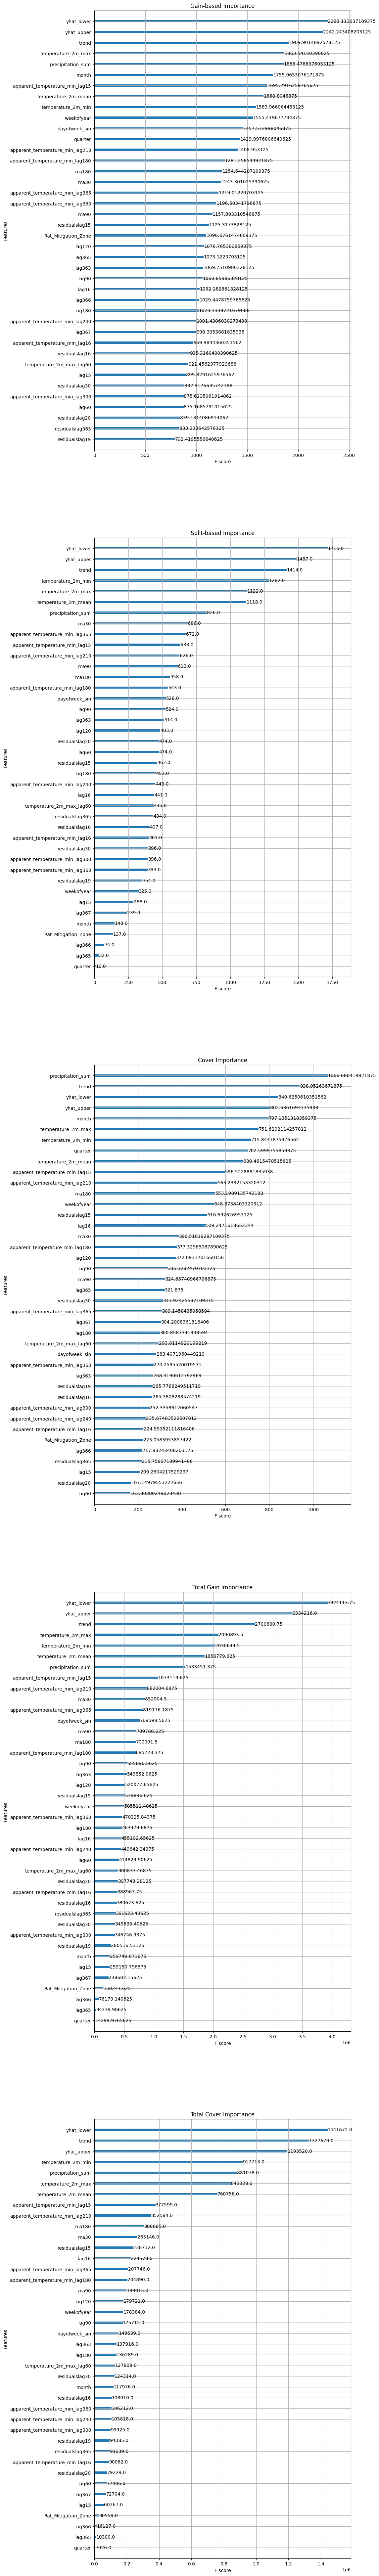

In [16]:
fig, (ax1, ax2, ax3, ax4, ax5) = plt.subplots(5, 1, figsize=(10, 100))
plot_importance(xgb_model, ax=ax1, importance_type='gain')
ax1.set_title('Gain-based Importance', fontsize=12)

plot_importance(xgb_model, ax=ax2, importance_type='weight')
ax2.set_title('Split-based Importance', fontsize=12)

plot_importance(xgb_model, ax=ax3, importance_type='cover')
ax3.set_title('Cover Importance', fontsize=12)

plot_importance(xgb_model, ax=ax4, importance_type='total_gain')
ax4.set_title('Total Gain Importance', fontsize=12)

plot_importance(xgb_model, ax=ax5, importance_type='total_cover')
ax5.set_title('Total Cover Importance', fontsize=12)